In [10]:
# M24CA1L306 Data Science Lab - Lab Exercise #08
# Student: Abhinav | MAC25MCA-2002 | S3 MCA (2025-27)
# Dataset: titanic3.csv (1309 passengers, 14 variables)
# Task: kNN for passenger survival prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

In [11]:
# ─────────────────────────────────────────────
# Load and preprocess
# ─────────────────────────────────────────────
df = pd.read_csv("../Datasets/Titanic.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

# Keep only useful features for kNN
# Drop: name, ticket, cabin, boat, body, home.dest (too sparse or leak survival)
df = df[["Pclass", "Survived", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]

# Fill missing values
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Fare"].fillna(df["Fare"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Encode categoricals
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])          # male=1, female=0
df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])  # C=0, Q=1, S=2

print("\nAfter preprocessing:\n", df.head())
print("\nClass balance:\n", df["Survived"].value_counts())

X = df.drop("Survived", axis=1).values
y = df["Survived"].values


Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

After preprocessing:
    Pclass  Survived  Sex   Age  SibSp  Parch     Fare  Embarked
0       3         0    1  22.0      1      0   7.2500         2
1       1         1    0  38.0      1      0  71.2833         0
2       3         1    0  26.0      0      0   7.9250         2
3       1         1    0  35.0      1      0  53.1000         2
4       3         0    1  35.0      0      0   8.0500         2

Class balance:
 Survived
0    549
1    342
Name: count, dtype: int64


In [12]:

# ─────────────────────────────────────────────
# Task 1: kNN survival prediction (k=5, scaled)
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred = knn.predict(X_test_sc)

print("\n" + "="*50)
print("Task 1: kNN Survival Prediction (k=5, scaled)")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))



Task 1: kNN Survival Prediction (k=5, scaled)
Accuracy: 0.8101

Classification Report:
                 precision    recall  f1-score   support

Did not survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179




Task 2: Effect of k on Accuracy
Best k = 12 with test accuracy = 0.8212
k=1 train acc = 0.9747, test acc = 0.7765
k=2 train acc = 0.8806, test acc = 0.7989
k=3 train acc = 0.8764, test acc = 0.8101
k=25 train acc = 0.8188, test acc = 0.7877 (underfitting check)


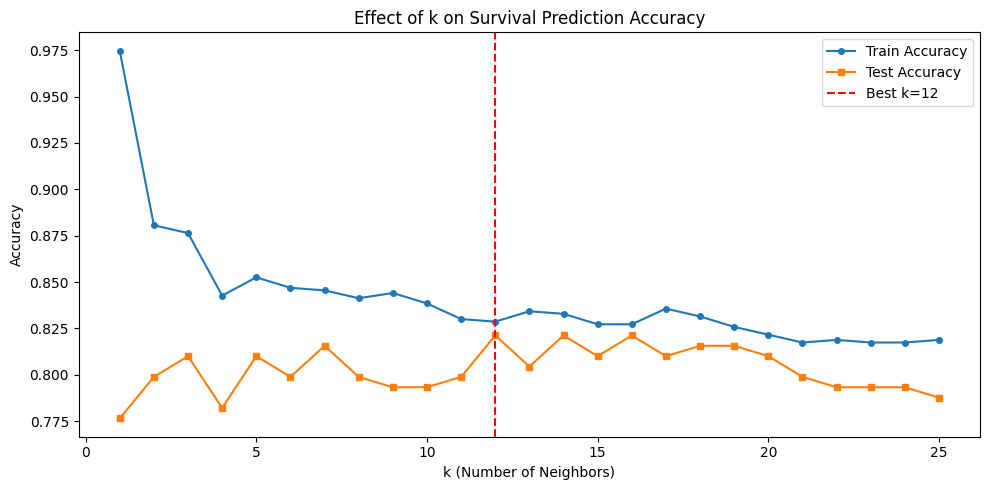

In [17]:

# ─────────────────────────────────────────────
# Task 2: Effect of k on accuracy
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("Task 2: Effect of k on Accuracy")
print("="*50)

k_values = list(range(1, 26))
train_accs, test_accs = [], []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_sc, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train_sc)))
    test_accs.append(accuracy_score(y_test,  clf.predict(X_test_sc)))

best_k = k_values[test_accs.index(max(test_accs))]
print(f"Best k = {best_k} with test accuracy = {max(test_accs):.4f}")
print(f"k=1 train acc = {train_accs[0]:.4f}, test acc = {test_accs[0]:.4f}")
print(f"k=2 train acc = {train_accs[1]:.4f}, test acc = {test_accs[1]:.4f}")
print(f"k=3 train acc = {train_accs[2]:.4f}, test acc = {test_accs[2]:.4f}")
print(f"k=25 train acc = {train_accs[-1]:.4f}, test acc = {test_accs[-1]:.4f} (underfitting check)")

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accs, label="Train Accuracy", marker="o", markersize=4)
plt.plot(k_values, test_accs,  label="Test Accuracy",  marker="s", markersize=4)
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("Effect of k on Survival Prediction Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("../Outputs/Lab-8_Output/lab08_task2_k_vs_accuracy.png", dpi=100)
plt.show()

# Findings: k=1 gives 100% train accuracy (clear overfitting) but lower test accuracy.
# As k increases, test accuracy stabilises. Optimal k balances both.



Task 3: Feature Scaling vs No Scaling
Best accuracy WITH scaling    : 0.8212  at k=12
Best accuracy WITHOUT scaling : 0.7039  at k=10


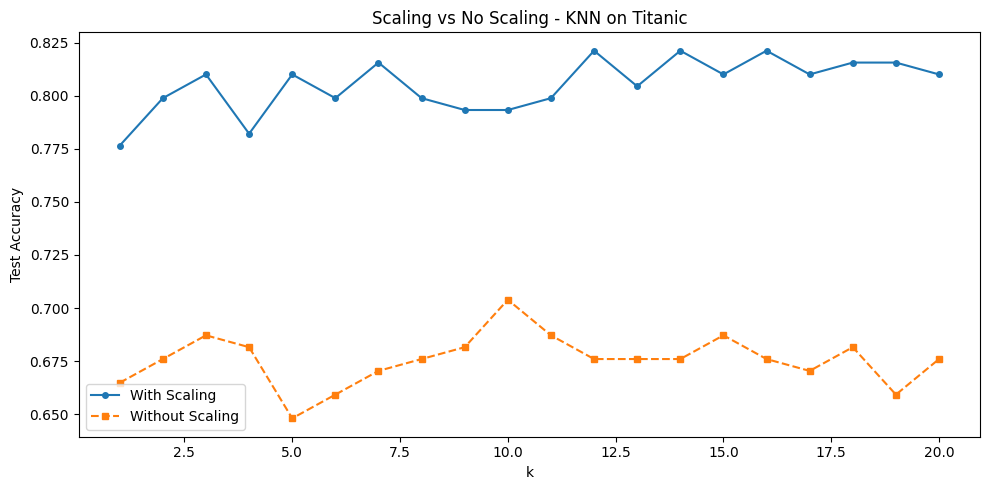

In [14]:

# ─────────────────────────────────────────────
# Task 3: Scaling vs No Scaling
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("Task 3: Feature Scaling vs No Scaling")
print("="*50)

k_values_cmp = list(range(1, 21))
acc_scaled, acc_unscaled = [], []

for k in k_values_cmp:
    clf = KNeighborsClassifier(n_neighbors=k)

    clf.fit(X_train_sc, y_train)
    acc_scaled.append(accuracy_score(y_test, clf.predict(X_test_sc)))

    clf.fit(X_train, y_train)
    acc_unscaled.append(accuracy_score(y_test, clf.predict(X_test)))

print(f"Best accuracy WITH scaling    : {max(acc_scaled):.4f}  at k={k_values_cmp[acc_scaled.index(max(acc_scaled))]}")
print(f"Best accuracy WITHOUT scaling : {max(acc_unscaled):.4f}  at k={k_values_cmp[acc_unscaled.index(max(acc_unscaled))]}")

plt.figure(figsize=(10, 5))
plt.plot(k_values_cmp, acc_scaled,   label="With Scaling",    marker="o", markersize=4)
plt.plot(k_values_cmp, acc_unscaled, label="Without Scaling", marker="s", markersize=4, linestyle="--")
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("Scaling vs No Scaling - KNN on Titanic")
plt.legend()
plt.tight_layout()
plt.savefig("../Outputs/Lab-8_Output/lab08_task3_scaling.png", dpi=100)
plt.show()

# Findings: Scaling improves accuracy, especially at small k. Without scaling,
# fare (range: 0-512) dominates distance calculations over pclass (1-3).



Task 4: Confusion Matrix Analysis
True Negatives  (correctly predicted not Survived): 97
False Positives (predicted Survived, actually not): 13
False Negatives (predicted not Survived, actually did): 21
True Positives  (correctly predicted Survived): 48

False Positive Rate : 0.1182
False Negative Rate : 0.3043

More common error: False Negatives (predicted death when passenger actually Survived)


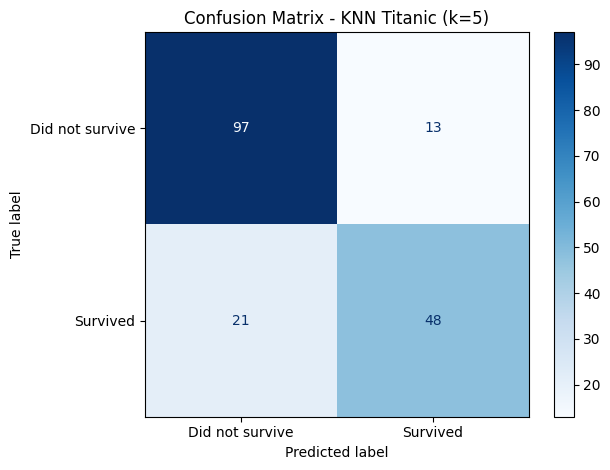

In [15]:

# ─────────────────────────────────────────────
# Task 4: Confusion Matrix
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("Task 4: Confusion Matrix Analysis")
print("="*50)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives  (correctly predicted not Survived): {tn}")
print(f"False Positives (predicted Survived, actually not): {fp}")
print(f"False Negatives (predicted not Survived, actually did): {fn}")
print(f"True Positives  (correctly predicted Survived): {tp}")
print(f"\nFalse Positive Rate : {fp / (fp + tn):.4f}")
print(f"False Negative Rate : {fn / (fn + tp):.4f}")

if fp > fn:
    print("\nMore common error: False Positives (predicted survival when passenger did not survive)")
else:
    print("\nMore common error: False Negatives (predicted death when passenger actually Survived)")

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Did not survive", "Survived"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - KNN Titanic (k=5)")
plt.tight_layout()
plt.savefig("../Outputs/Lab-8_Output/lab08_task4_confusion_matrix.png", dpi=100)
plt.show()

# Findings: False negatives are typically more common - the model tends to
# predict death more often because the majority class (did not survive) pulls
# kNN decisions toward the non-survival label.



Task 5: Stability Across Train-Test Splits
Accuracies across 10 random splits: [0.7933, 0.8324, 0.8436, 0.8436, 0.8212, 0.8045, 0.8156, 0.7765, 0.8324, 0.8324]
Mean : 0.8196
Std  : 0.0211

10-Fold CV scores: [0.8111 0.7978 0.7528 0.809  0.8539 0.7978 0.7865 0.7753 0.8539 0.809 ]
CV Mean : 0.8047
CV Std  : 0.0299


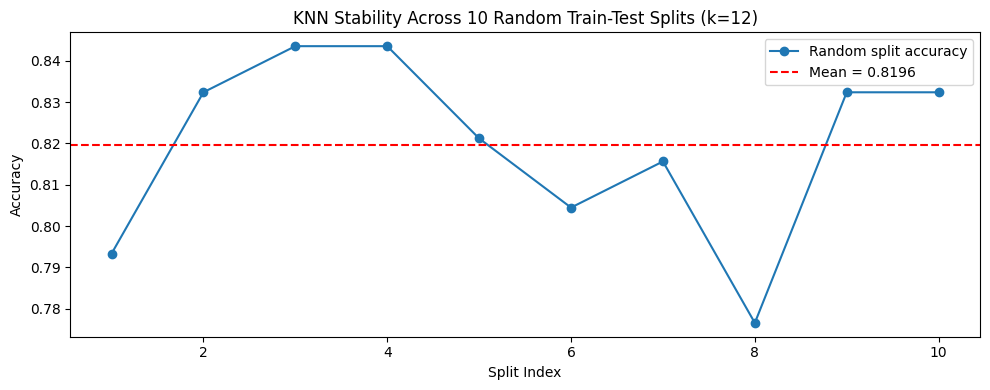


All tasks complete. Plots saved.


In [16]:

# ─────────────────────────────────────────────
# Task 5: Stability across different train-test splits
# ─────────────────────────────────────────────
print("\n" + "="*50)
print("Task 5: Stability Across Train-Test Splits")
print("="*50)

# Method 1: Different random seeds
seeds = list(range(10))
split_accs = []
for seed in seeds:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2,
                                           random_state=seed, stratify=y)
    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    Xte_sc = sc.transform(Xte)
    clf = KNeighborsClassifier(n_neighbors=best_k)
    clf.fit(Xtr_sc, ytr)
    split_accs.append(accuracy_score(yte, clf.predict(Xte_sc)))

print(f"Accuracies across 10 random splits: {[round(a, 4) for a in split_accs]}")
print(f"Mean : {np.mean(split_accs):.4f}")
print(f"Std  : {np.std(split_accs):.4f}")

# Method 2: 10-fold cross-validation
sc_full = StandardScaler()
X_full_sc = sc_full.fit_transform(X)
cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=best_k),
                             X_full_sc, y, cv=10, scoring="accuracy")
print(f"\n10-Fold CV scores: {cv_scores.round(4)}")
print(f"CV Mean : {cv_scores.mean():.4f}")
print(f"CV Std  : {cv_scores.std():.4f}")

plt.figure(figsize=(10, 4))
plt.plot(range(1, 11), split_accs, marker="o", label="Random split accuracy")
plt.axhline(np.mean(split_accs), color="red", linestyle="--",
            label=f"Mean = {np.mean(split_accs):.4f}")
plt.xlabel("Split Index")
plt.ylabel("Accuracy")
plt.title(f"KNN Stability Across 10 Random Train-Test Splits (k={best_k})")
plt.legend()
plt.tight_layout()
plt.savefig("../Outputs/Lab-8_Output/lab08_task5_stability.png", dpi=100)
plt.show()

# Findings: Low std across splits indicates stable predictions. Cross-validation
# confirms the model generalises consistently rather than depending on one lucky split.

print("\nAll tasks complete. Plots saved.")